<a href="https://colab.research.google.com/github/porterolson/march-madness-ml/blob/main/march_madness_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Install packages

In [ ]:
!pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11679 sha256=2462d7dd978b8b0d1f5188e87b39197a0990e39fd3fa2051c20d5808d257e503
  Stored in directory: /root/.cache/pip/wheels/8f/ab/cb/45ccc40522d3a1c41e1d2ad53b8f33a62f394011ec38cd71c6
Successfully built wikipedia


# Import Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import wikipedia as wp
from sklearn.preprocessing import StandardScaler

# Data For End of season (need to add more)

In [ ]:
import pandas as pd

# Create an empty list to store DataFrames
df_list = []

# Loop through the years and read CSVs
for i in range(13, 24):
    file_name = f'/content/gdrive/MyDrive/Files for Colab/kaggle_march_madness/cbb{i}.csv'  # Path to your CSVs
    df = pd.read_csv(file_name)

    df['YEAR'] = np.int64(2000+i)  # Correctly assign the year column

    df_list.append(df)  # Append DataFrame to the list

# Concatenate all DataFrames into a single DataFrame
df_combined = pd.concat(df_list, ignore_index=True)
df_combined['L']=df['G']-df['W']

columns_to_drop = ['RK', 'EFGD_D','G','W','L','SEED','ADJ_T','ADJDE','ADJOE','CONF']

# Drop the columns
df_combined.drop(columns=columns_to_drop, inplace=True, errors='ignore')

rename_dict = {
    'TEAM': 'Team',
    'YEAR': 'Year'
}

# Apply renaming while keeping unmatched columns unchanged
df_combined.rename(columns=rename_dict, inplace=True)


print(df_combined.columns)

teamsMM = df_combined[df_combined['Year'] == 2017].groupby('Team')['POSTSEASON'].unique()
print(teamsMM)



Index(['Team', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR',
       'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'WAB', 'POSTSEASON', 'Year'],
      dtype='object')
Team
Abilene Christian    [nan]
Air Force            [nan]
Akron                [nan]
Alabama              [nan]
Alabama A&M          [nan]
                     ...  
Wright St.           [nan]
Wyoming              [nan]
Xavier                [E8]
Yale                 [nan]
Youngstown St.       [nan]
Name: POSTSEASON, Length: 351, dtype: object


ken pom data as well

In [ ]:
kenpom=pd.read_csv('/content/gdrive/MyDrive/Files for Colab/kenpomData/kenpom.csv')
columns_to_drop = ['Rank', 'AdjustO Rank', 'AdjustD Rank','AdjustT Rank','Luck', 'Luck Rank','SOS Pyth Rank','SOS OppO Rank','SOS OppD Rank','NCSOS Pyth Rank']
kenpom.drop(columns=columns_to_drop, inplace=True, errors='ignore')


kenpom.rename(columns={
    'Team': 'Team',
    'Conference': 'Conf',
    'Wins': 'W',
    'Losses': 'L',
    'Pyth': 'NetRtg',         # Net Rating
    'AdjustO': 'ORtg',        # Offensive Rating
    'AdjustD': 'DRtg',        # Defensive Rating
    'AdjustT': 'AdjT',        # Adjusted Tempo
    'SOS Pyth': 'SOSNetRtg',  # Strength of Schedule Net Rating
    'SOS OppO': 'OpORtg',     # Opponent Offensive Rating
    'SOS OppD': 'OpDRtg',     # Opponent Defensive Rating
    'NCSOS Pyth': 'NCSOS NetRtg'  # Non-Conference Strength of Schedule Net Rating
}, inplace=True)



kenpom['Year']=kenpom['Year'].astype(int)
print(type(kenpom['Year']))
print(kenpom.columns)

kenpom

<class 'pandas.core.series.Series'>
Index(['Year', 'Team', 'Conf', 'W', 'L', 'Seed', 'NetRtg', 'ORtg', 'DRtg',
       'AdjT', 'SOSNetRtg', 'OpORtg', 'OpDRtg', 'NCSOS NetRtg'],
      dtype='object')


,Year,Team,Conf,W,L,Seed,NetRtg,ORtg,DRtg,AdjT,SOSNetRtg,OpORtg,OpDRtg,NCSOS NetRtg
0,2002,Duke,ACC,31,4,1.0,34.19,121.0,86.8,74.5,9.87,109.3,99.5,6.66
1,2002,Cincinnati,CUSA,31,4,1.0,30.19,118.1,87.9,67.4,6.58,106.5,100.0,3.48
2,2002,Maryland,ACC,32,4,1.0,29.25,119.2,89.9,73.7,9.88,109.4,99.5,1.62
3,2002,Kansas,B12,33,4,1.0,28.99,118.7,89.7,77.3,10.67,110.5,99.9,8.32
4,2002,Oklahoma,B12,31,5,2.0,26.04,114.9,88.9,66.5,8.77,109.2,100.4,-0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5448,2017,Longwood,BSth,6,24,NaN,-25.15,92.2,117.3,70.5,-5.80,101.5,107.3,-0.55
5449,2017,Arkansas Pine Bluff,SWAC,7,25,NaN,-25.28,85.7,111.0,67.6,-9.35,100.4,109.7,2.79
5450,2017,North Carolina A&T,MEAC,3,29,NaN,-27.71,95.4,123.1,62.8,-9.40,98.7,108.1,0.08
5451,2017,Presbyterian,BSth,5,25,NaN,-29.20,88.9,118.1,64.1,-4.36,102.8,107.1,2.25


In [ ]:
kenpom['Team'] = kenpom['Team'].astype(str).str.strip()
df_combined['Team'] = df_combined['Team'].astype(str).str.strip()

In [ ]:
merged_data = pd.merge(
    kenpom, df_combined,
    how='outer',  # Use 'inner' to keep only matching teams, or 'left'/'right' if needed
    on=['Year', 'Team']
)

merged_data = merged_data.applymap(lambda x: x.strip() if isinstance(x, str) else x)

print(merged_data.columns)
merged_data

Index(['Year', 'Team', 'Conf', 'W', 'L', 'Seed', 'NetRtg', 'ORtg', 'DRtg',
       'AdjT', 'SOSNetRtg', 'OpORtg', 'OpDRtg', 'NCSOS NetRtg', 'BARTHAG',
       'EFG_O', 'EFG_D', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O',
       '2P_D', '3P_O', '3P_D', 'WAB', 'POSTSEASON'],
      dtype='object')


,Year,Team,Conf,W,L,Seed,NetRtg,ORtg,DRtg,AdjT,...,ORB,DRB,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,WAB,POSTSEASON
0,2002,Air Force,MWC,9.0,19.0,NaN,-1.64,103.8,105.5,54.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2002,Akron,MAC,9.0,21.0,NaN,-5.94,105.2,111.2,65.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2002,Alabama,SEC,27.0,8.0,2.0,18.73,114.0,95.3,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2002,Alabama A&M,SWAC,17.0,10.0,NaN,-9.53,92.2,101.7,79.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2002,Alabama St.,SWAC,18.0,12.0,NaN,-12.62,90.1,102.7,63.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7576,2023,Wright St.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,26.2,26.6,24.0,27.6,53.9,51.2,35.1,32.6,-11.0,NaN
7577,2023,Wyoming,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.2,25.3,33.4,28.9,51.3,52.6,34.7,36.4,-11.7,NaN
7578,2023,Xavier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.8,25.0,31.4,27.0,53.8,48.6,39.0,35.8,5.4,S16
7579,2023,Yale,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.0,23.2,30.6,33.9,52.4,45.7,35.8,32.6,-2.0,NaN


In [ ]:
data = merged_data[(merged_data['Year'] >= 2013) & (merged_data['Year'] <= 2017)]
data.columns


columns_to_drop = ['W', 'L', 'NetRtg','SOSNetRtg', 'OpORtg','OpDRtg','NCSOS NetRtg','BARTHAG','WAB','POSTSEASON','DRtg']

seedData=data[['Year','Team','Seed']]


# Drop the columns
data.drop(columns=columns_to_drop, inplace=True, errors='ignore')
data




,Year,Team,Conf,Seed,ORtg,AdjT,EFG_O,EFG_D,TOR,TORD,ORB,DRB,FTR,FTRD,2P_O,2P_D,3P_O,3P_D
3702,2013,Air Force,MWC,NaN,111.7,63.2,54.7,51.9,18.5,19.1,23.7,31.8,30.8,36.6,52.9,54.2,38.1,32.4
3703,2013,Akron,MAC,12.0,106.8,65.2,51.0,44.6,20.8,20.2,37.6,30.5,36.9,35.0,52.1,42.7,32.7,32.8
3704,2013,Alabama,SEC,NaN,103.6,60.5,47.9,45.7,19.9,22.6,32.0,32.9,33.9,32.7,47.1,45.2,33.0,31.3
3705,2013,Alabama A&M,SWAC,NaN,90.8,64.9,43.8,49.8,21.0,17.4,31.8,31.9,36.9,36.0,43.9,48.8,28.9,34.9
3706,2013,Alabama St.,SWAC,NaN,92.3,64.8,45.1,49.4,22.0,19.5,33.4,34.5,32.2,38.0,44.8,47.6,30.6,35.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5451,2017,Wright St.,Horz,NaN,106.5,69.0,52.0,52.0,20.4,19.5,29.4,26.5,38.0,37.1,49.4,52.0,37.2,34.8
5452,2017,Wyoming,MWC,NaN,104.8,72.9,51.6,46.2,17.7,16.2,22.7,27.7,37.5,39.4,50.7,45.7,35.1,31.4
5453,2017,Xavier,BE,11.0,115.7,67.2,51.9,51.6,18.4,17.5,34.5,25.5,41.1,33.4,52.0,52.5,34.5,33.4
5454,2017,Yale,Ivy,NaN,106.2,68.2,52.3,49.7,19.3,17.0,31.2,28.5,33.9,26.3,51.8,49.6,35.5,33.2


# Data by game

In [ ]:
import pandas as pd

# Define the exact columns to keep
columns_to_keep = [
    'GameId', 'Season', 'SeasonLabel', 'SeasonType', 'TeamId', 'Team',
    'Conference', 'OpponentId', 'Opponent', 'Pace', 'Offense Rating',
    'Offense Points Total', 'Offense TwoPointFieldGoals Pct',
    'Offense ThreePointFieldGoals Pct',
    'Offense FourFactors EffectiveFieldGoalPct',
    'Offense FourFactors FreeThrowRate',
    'Offense FourFactors TurnoverRatio',
    'Offense FourFactors OffensiveReboundPct', 'Defense Rating',
    'Defense Points Total', 'Defense TwoPointFieldGoals Pct',
    'Defense ThreePointFieldGoals Pct',
    'Defense FourFactors EffectiveFieldGoalPct',
    'Defense FourFactors FreeThrowRate',
    'Defense FourFactors TurnoverRatio',
    'Defense FourFactors OffensiveReboundPct'
]

# Create an empty list to store DataFrames
df_list = []

# Loop through the years and read CSVs
for i in range(14, 19):
    file_name = f'/content/gdrive/MyDrive/Files for Colab/gameData March Madness/download ({i}).csv'  # Path to your CSVs

    # Read only the selected columns
    df = pd.read_csv(file_name, usecols=columns_to_keep, low_memory=False)

    df_list.append(df)  # Append DataFrame to the list

# Concatenate all DataFrames into a single DataFrame
df_game= pd.concat(df_list, ignore_index=True)

cleaning df_game

In [ ]:
df_game['Win'] = (df_game['Defense Points Total'] < df_game['Offense Points Total']).astype(int)

# Define the columns to drop
columns_to_drop = ['SeasonLabel', 'SeasonType','Defense Rating']

# Drop the columns from the DataFrame
df_game = df_game.drop(columns=columns_to_drop, errors='ignore')

##add a column which is own seed, or maybe do conference rating, like rate teh conferences

rename_dict = {
    'Pace': 'AdjT',
    'Offense Rating': 'ORtg',
    'Offense TwoPointFieldGoals Pct':'2P_O',
    'Offense ThreePointFieldGoals Pct':'3P_O',
    'Offense FourFactors EffectiveFieldGoalPct':'EFG_O',
    'Offense FourFactors FreeThrowRate':'FTR',
    'Offense FourFactors TurnoverRatio':'TOR',
    'Offense FourFactors OffensiveReboundPct':'ORB',
    'Defense TwoPointFieldGoals Pct':'2P_D',
    'Defense ThreePointFieldGoals Pct':'3P_D',
    'Defense FourFactors EffectiveFieldGoalPct':'EFG_D',
    'Defense FourFactors FreeThrowRate':'FTRD',
    'Defense FourFactors TurnoverRatio':'TORD',
    'Defense FourFactors OffensiveReboundPct':'DRB',
    'Season':'Year'


}

#Year	Team	Seed	ORtg	AdjT	EFG_O	EFG_D	TOR	TORD	ORB	DRB	FTR	FTRD	2P_O	2P_D	3P_O	3P_D

# Apply renaming while keeping unmatched columns unchanged
df_game.rename(columns=rename_dict, inplace=True)

In [ ]:
# Define conference categories
top_conferences = ['ACC', 'Big 12', 'Big East', 'Big Ten', 'SEC']
pac12_conference = ['Pac-12']

# Assign values based on conference membership
df_game['Top'] = df_game['Conference'].apply(
    lambda x: 2 if x in top_conferences else (1 if x in pac12_conference else 0)
)

df_game=df_game.reset_index(drop=True)


In [ ]:
# Select rows where the index is even (including zero)
df_even = df_game.iloc[::2].reset_index(drop=True)

# Select rows where the index is odd
df_odd = df_game.iloc[1::2].reset_index(drop=True)

In [ ]:
twoTeamdf=pd.merge(df_even,df_odd,how='outer',on=['GameId','Year'])
twoTeamdf

,GameId,Year,TeamId_x,Team_x,Conference_x,OpponentId_x,Opponent_x,AdjT_x,ORtg_x,Offense Points Total_x,...,ORB_y,Defense Points Total_y,2P_D_y,3P_D_y,EFG_D_y,FTRD_y,TORD_y,DRB_y,Win_y,Top_y
0,5880,2024,199,North Carolina Central,MEAC,131,Kansas,65.5,86.2,56,...,10.8,56,41.2,26.1,40.4,31.6,13.8,39.1,1,2
1,5881,2024,62,Dartmouth,Ivy,72,Duke,66.5,81.8,54,...,15.2,54,39.5,22.2,37.5,30.4,19.7,34.5,1,2
2,5882,2024,256,Samford,SoCon,236,Purdue,75.0,60.0,45,...,22.2,45,32.4,16.1,28.7,20.6,20.0,42.4,1,2
3,5883,2024,129,James Madison,Sun Belt,169,Michigan State,74.7,94.0,79,...,35.4,79,43.6,27.6,42.6,41.2,17.9,27.5,0,2
4,5884,2024,208,Northern Illinois,MAC,157,Marquette,72.5,95.9,70,...,31.7,70,43.2,26.9,42.1,22.9,19.2,45.0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7841,43425,2018,176,Missouri State,MVC,270,South Dakota State,61.5,117.7,73,...,30.0,73,55.3,37.5,55.6,9.7,12.9,26.8,0,0
7842,43426,2018,167,Miami (OH),MAC,349,Western Illinois,64.4,95.0,76,...,20.5,76,50.0,32.1,49.2,27.3,17.5,25.0,0,0
7843,43427,2018,297,Texas State,Sun Belt,112,Houston Christian,65.0,80.0,52,...,25.6,52,41.0,10.0,32.2,32.2,16.9,50.0,1,0
7844,43428,2018,234,Princeton,Ivy,168,Miami,66.0,80.0,52,...,20.5,52,37.9,25.0,37.7,14.8,16.9,32.3,1,2


In [ ]:
twoTeamdf.columns

Index(['GameId', 'Year', 'TeamId_x', 'Team_x', 'Conference_x', 'OpponentId_x',
       'Opponent_x', 'AdjT_x', 'ORtg_x', 'Offense Points Total_x', '2P_O_x',
       '3P_O_x', 'EFG_O_x', 'FTR_x', 'TOR_x', 'ORB_x',
       'Defense Points Total_x', '2P_D_x', '3P_D_x', 'EFG_D_x', 'FTRD_x',
       'TORD_x', 'DRB_x', 'Win_x', 'Top_x', 'TeamId_y', 'Team_y',
       'Conference_y', 'OpponentId_y', 'Opponent_y', 'AdjT_y', 'ORtg_y',
       'Offense Points Total_y', '2P_O_y', '3P_O_y', 'EFG_O_y', 'FTR_y',
       'TOR_y', 'ORB_y', 'Defense Points Total_y', '2P_D_y', '3P_D_y',
       'EFG_D_y', 'FTRD_y', 'TORD_y', 'DRB_y', 'Win_y', 'Top_y'],
      dtype='object')

# Preprocessing



Ok, rn i am thinking about doing groupby game

mabye do a group by game

In [ ]:
#TODO: try using def instead of offensive rating,

#maybe while training do it so it trains on a game, so we can have it do two teams at the same time


##scale teh x's

y=twoTeamdf['Win_x']
cols_to_remove = ['Win', 'TeamId', 'Team', 'OpponentId', 'Opponent',
                  'GameId', 'Offense Points Total', 'Defense Points Total',
                  'Year','Conference_x','Conference_y']



newdf=twoTeamdf

for col in ['AdjT', 'ORtg', '2P_O', '3P_O', 'EFG_O', 'FTR', 'TOR',
            'ORB', '2P_D', '3P_D', 'EFG_D', 'FTRD', 'TORD', 'DRB', 'Top']:
    newdf[f"{col}_Diff"] = newdf[f"{col}_x"] - newdf[f"{col}_y"]

# Select only the newly created difference columns for model input
X = newdf[[col for col in newdf.columns if '_Diff' in col]]

X

# # Generate the full column names with _x and _y versions
# columns_to_drop = [col for col in twoTeamdf.columns if any(base_col in col for base_col in cols_to_remove)]

# # Drop the identified columns
# X = twoTeamdf.drop(columns=columns_to_drop)
# X.columns

,AdjT_Diff,ORtg_Diff,2P_O_Diff,3P_O_Diff,EFG_O_Diff,FTR_Diff,TOR_Diff,ORB_Diff,2P_D_Diff,3P_D_Diff,EFG_D_Diff,FTRD_Diff,TORD_Diff,DRB_Diff,Top_Diff
0,0.0,-63.8,-37.6,-30.4,-40.9,13.7,-1.4,28.3,37.6,30.4,40.9,-13.7,1.4,-28.3,-2
1,0.0,-55.5,-34.3,-19.0,-32.8,10.1,6.3,19.3,34.3,19.0,32.8,-10.1,-6.3,-19.3,-2
2,0.0,-70.7,-22.1,-39.1,-39.0,-14.9,0.0,20.2,22.1,39.1,39.0,14.9,0.0,-20.2,-2
3,0.0,3.5,-4.5,22.6,5.8,-10.2,4.8,-7.9,4.5,-22.6,-5.8,10.2,-4.8,7.9,-2
4,0.0,-31.9,-18.7,-9.1,-16.9,-8.4,6.7,13.3,18.7,9.1,16.9,8.4,-6.7,-13.3,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7841,0.0,30.8,3.9,25.0,17.5,-10.6,1.4,-3.2,-3.9,-25.0,-17.5,10.6,-1.4,3.2,0
7842,0.0,4.9,4.1,-4.6,-0.8,13.9,-4.7,4.5,-4.1,4.6,0.8,-13.9,4.7,-4.5,0
7843,0.0,-29.2,-23.9,-18.6,-26.6,6.7,-10.8,24.4,23.9,18.6,26.6,-6.7,10.8,-24.4,0
7844,0.0,-39.4,-7.8,-31.0,-24.0,-0.2,-1.0,11.8,7.8,31.0,24.0,0.2,1.0,-11.8,-2


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
scaler.fit(X)
scaler.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Models

Random Forest

Cross Validation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

# Initialize the Random Forest classifier
MMrf = RandomForestClassifier(n_estimators=100, random_state=21,n_jobs=-1,)


#use gridsearchcv to do cross validation
from sklearn.model_selection import GridSearchCV
# define grid for alpha
grid = {'max_depth': [9,10,11,12,13,14,15],'min_samples_leaf': [1,2,3,4,5],'min_samples_split': [1,2,3,4,5,6]}
grid_search = GridSearchCV(MMrf,grid,cv=5,return_train_score=True)
best_model=grid_search.fit(X_train,y_train)
print(best_model.best_params_)
print(best_model.best_estimator_)



KeyboardInterrupt: 

0.9810388782664117
0.9738853503184713


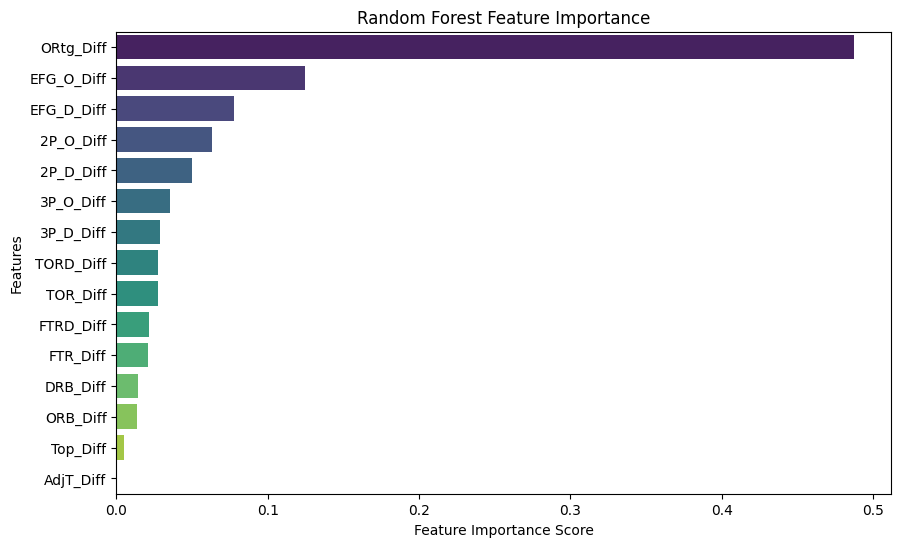

In [ ]:
import seaborn as sns

MMrf = RandomForestClassifier(n_estimators=100, random_state=21,n_jobs=-1,max_depth=13,min_samples_leaf=1)
MMrf.fit(X_train,y_train)
#get the score
print(MMrf.score(X_train,y_train))
print(MMrf.score(X_test,y_test))

#show importances graph
importances = MMrf.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feat_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances['Importance'], y=feat_importances['Feature'], palette='viridis')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

Do a out of sample test very simply with the data I have

In [ ]:
# Define conference categories
top_conferences = ['ACC', 'B12', 'BE', 'B10', 'SEC']
pac12_conference = ['P12']

# Assign values based on conference membership
data['Top'] = data['Conf'].apply(
    lambda x: 2 if x in top_conferences else (1 if x in pac12_conference else 0)
)

data=data.reset_index(drop=True)
data

,Year,Team,Conf,Seed,ORtg,AdjT,EFG_O,EFG_D,TOR,TORD,ORB,DRB,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,Top
0,2013,Air Force,MWC,NaN,111.7,63.2,54.7,51.9,18.5,19.1,23.7,31.8,30.8,36.6,52.9,54.2,38.1,32.4,0
1,2013,Akron,MAC,12.0,106.8,65.2,51.0,44.6,20.8,20.2,37.6,30.5,36.9,35.0,52.1,42.7,32.7,32.8,0
2,2013,Alabama,SEC,NaN,103.6,60.5,47.9,45.7,19.9,22.6,32.0,32.9,33.9,32.7,47.1,45.2,33.0,31.3,2
3,2013,Alabama A&M,SWAC,NaN,90.8,64.9,43.8,49.8,21.0,17.4,31.8,31.9,36.9,36.0,43.9,48.8,28.9,34.9,0
4,2013,Alabama St.,SWAC,NaN,92.3,64.8,45.1,49.4,22.0,19.5,33.4,34.5,32.2,38.0,44.8,47.6,30.6,35.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1749,2017,Wright St.,Horz,NaN,106.5,69.0,52.0,52.0,20.4,19.5,29.4,26.5,38.0,37.1,49.4,52.0,37.2,34.8,0
1750,2017,Wyoming,MWC,NaN,104.8,72.9,51.6,46.2,17.7,16.2,22.7,27.7,37.5,39.4,50.7,45.7,35.1,31.4,0
1751,2017,Xavier,BE,11.0,115.7,67.2,51.9,51.6,18.4,17.5,34.5,25.5,41.1,33.4,52.0,52.5,34.5,33.4,2
1752,2017,Yale,Ivy,NaN,106.2,68.2,52.3,49.7,19.3,17.0,31.2,28.5,33.9,26.3,51.8,49.6,35.5,33.2,0


# pick two teams RF

In [ ]:
#data for 2017
data2017=data[data['Year']==2017]
#make an id for each team
data2017['TeamId']=data2017['Team'].astype('category').cat.codes
data2017

,Year,Team,Conf,Seed,ORtg,AdjT,EFG_O,EFG_D,TOR,TORD,ORB,DRB,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,Top,TeamId
1403,2017,Abilene Christian,Slnd,NaN,97.0,65.8,52.5,52.8,21.0,21.4,23.0,31.7,34.7,44.3,50.7,52.1,37.1,36.1,0,0
1404,2017,Air Force,MWC,NaN,104.3,67.1,49.8,54.6,17.9,17.5,26.5,24.6,37.4,32.6,47.0,54.4,36.2,36.6,0,1
1405,2017,Akron,MAC,NaN,112.6,66.3,55.1,51.0,17.2,16.7,29.4,27.9,37.3,32.9,55.0,49.0,36.8,36.8,0,2
1406,2017,Alabama,SEC,NaN,105.3,65.1,48.2,46.1,20.4,19.8,34.1,26.6,39.1,39.9,48.7,44.2,31.7,33.3,2,3
1407,2017,Alabama A&M,SWAC,NaN,91.4,64.3,44.3,53.7,19.8,14.0,29.3,36.2,39.5,33.7,45.6,53.2,27.5,36.3,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1749,2017,Wright St.,Horz,NaN,106.5,69.0,52.0,52.0,20.4,19.5,29.4,26.5,38.0,37.1,49.4,52.0,37.2,34.8,0,346
1750,2017,Wyoming,MWC,NaN,104.8,72.9,51.6,46.2,17.7,16.2,22.7,27.7,37.5,39.4,50.7,45.7,35.1,31.4,0,347
1751,2017,Xavier,BE,11.0,115.7,67.2,51.9,51.6,18.4,17.5,34.5,25.5,41.1,33.4,52.0,52.5,34.5,33.4,2,348
1752,2017,Yale,Ivy,NaN,106.2,68.2,52.3,49.7,19.3,17.0,31.2,28.5,33.9,26.3,51.8,49.6,35.5,33.2,0,349


In [ ]:
import warnings
warnings.filterwarnings('ignore')
print('Pick Team one....')
team1=input()
print('Pick Team two....')
team2=input()

def predict_win(team1, team2):


  #get team1 from data2017 and team2 from data2017
  team1data=data2017[data2017['Team']==team1]
  team2data=data2017[data2017['Team']==team2]
  pickedTeams=pd.merge(team1data,team2data,how='outer',on=['Year'])


  columns_to_drop = ['Conf_x','Conf_y','Seed_x','Seed_y','Year','Team_x','Team_y','Top Conference_x','Top Conference_y','TeamId_x','TeamId_y']
  pickedTeams = pickedTeams.drop(columns=columns_to_drop, errors='ignore')


  desired_order = ['AdjT_x', 'ORtg_x', '2P_O_x', '3P_O_x', 'EFG_O_x', 'FTR_x', 'TOR_x',
                  'ORB_x', '2P_D_x', '3P_D_x', 'EFG_D_x', 'FTRD_x', 'TORD_x', 'DRB_x',
                  'Top_x', 'AdjT_y', 'ORtg_y', '2P_O_y', '3P_O_y', 'EFG_O_y', 'FTR_y',
                  'TOR_y', 'ORB_y', '2P_D_y', '3P_D_y', 'EFG_D_y', 'FTRD_y', 'TORD_y',
                  'DRB_y', 'Top_y']

  newPicked=pickedTeams[desired_order]


  for col in ['AdjT', 'ORtg', '2P_O', '3P_O', 'EFG_O', 'FTR', 'TOR',
              'ORB', '2P_D', '3P_D', 'EFG_D', 'FTRD', 'TORD', 'DRB', 'Top']:
      newPicked[f"{col}_Diff"] = newPicked[f"{col}_x"] - newPicked[f"{col}_y"]

  # Select only the newly created difference columns for model input
  newPicked = newPicked[[col for col in newPicked.columns if '_Diff' in col]]

  win=MMrf.predict(newPicked)
  print('Will team one win? (1 yes, 0 no)',win)
  prob=MMrf.predict_proba(newPicked)[:, 1]
  print(f'Probability of Team 1 Winning:  ',prob)
  return prob

t1=predict_win(team1,team2) #.9
t2=predict_win(team2,team1) #.05

spread=t1-t2
print('Team 1 spread,',spread)
print('positive indicates they are favored in this game, negative is team2 favored')


Pick Team one....
Iowa St.
Pick Team two....
Purdue
Will team one win? (1 yes, 0 no) [1]
Probability of Team 1 Winning:   [0.9]
Will team one win? (1 yes, 0 no) [0]
Probability of Team 1 Winning:   [0.09904342]
Team 1 spread, [0.80095658]
positive indicates they are favored in this game, negative is team2 favored


XGboost

In [ ]:
#xgboost on xtrain and y train
from xgboost import XGBClassifier

model = xgb.XGBClassifier(
    objective='binary:logistic',  # Outputs win probabilities
    eval_metric='logloss',  # Maximizes likelihood (MLE)
    use_label_encoder=False,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred_binary = model.predict(X_test)  # Predict Win/Loss (0 or 1)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Predict probability of winning

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred_binary)
log_loss_value = log_loss(y_test, y_pred_prob)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Log Loss (Likelihood Maximization): {log_loss_value:.4f}")

# Display some example predictions
df_predictions = pd.DataFrame({
    'Actual Win': y_test.values,
    'Predicted Win': y_pred_binary,
    'Win Probability': y_pred_prob
})